# 00b · 벡터화: 반복문을 배열 연산으로

**이번 질문:** 같은 계산을 `for` 문 대신 배열 한 줄로 쓰면 왜 빠르고, 어떤 순서로 옮기나요?

00번에서 내적을 반복문으로도 쓰고 `x @ w`로도 썼습니다. 결과는 같았습니다. 그런데 딥러닝 코드에는 `for` 문이 거의 없습니다.
이미지 60,000장, 화소 784개, 가중치 수백만 개를 하나씩 도는 파이썬 반복문은 너무 느리기 때문입니다.
이 노트북은 **반복문을 배열 연산으로 옮기는 방법**을 익힙니다. 뒤의 모든 노트북 코드가 이 방식으로 쓰여 있습니다.

- 준비물: [00](00_math_to_numpy.ipynb)의 shape, 축, 브로드캐스팅.
- 도착점: 원소별 연산·축 합·브로드캐스팅·인덱싱 네 가지로 반복문 대부분을 없애고, 결과 모양을 먼저 적을 수 있습니다.
- 다음 연결: [01](01_gradients_and_learning.ipynb)의 학습 루프는 이 네 가지의 조합입니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 파이썬 반복문은 원소마다 인터프리터를 거치고, NumPy 배열 연산은 C로 짜인 반복문 하나로 처리합니다. 같은 계산이 수십에서 수백 배 빨라집니다.
2. 반복문을 옮기는 순서입니다. "무엇이 반복되나(축)" → "원소별 연산인가, 축을 없애는 합인가, 모양을 맞추는 브로드캐스팅인가, 골라내기인가".
3. 브로드캐스팅 규칙: **뒤 축부터** 비교해 같거나 1이면 통과, 축이 없으면 앞에 1을 붙입니다. 결과 모양을 먼저 적고 코드를 씁니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/vectorization_plots.py)


In [1]:
import sys
import time
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src.utils import setup_plots, run_check
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

from src.data.mnist import load_mnist, load_examples
from src.utils.vectorization_plots import (
    plot_timing_bars, plot_centering, plot_broadcast_shapes, plot_distance_grid, plot_indexing,
)

NumPy 2.3.5 · 준비 완료


### 📎 이 노트북의 예시: MNIST 5,000장

00번의 고정 예시 10장과 학습 집합 앞 5,000장을 씁니다. 5,000장이면 반복문과 배열 연산의 시간 차이가 눈에 띄고, 5초 안에 모든 셀이 끝납니다.

> **용어**
>
> - **실행 시간 재기**: `time.perf_counter()`로 앞뒤 시각을 재서 뺍니다. 같은 일을 여러 번 반복해 평균내면 흔들림이 줄어듭니다. 아래 `elapsed`가 그 도우미입니다.
> - **벡터화(vectorization)**: 파이썬 반복문으로 원소 하나씩 처리하던 계산을 배열 전체에 대한 NumPy 연산 한 번으로 바꾸는 것. 00번에서 한 번 나왔습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

In [2]:
def elapsed(function, repeats=5):
    """function()을 repeats번 실행한 평균 시간(초)."""
    start = time.perf_counter()
    for _ in range(repeats):
        function()
    return (time.perf_counter() - start) / repeats


example_images, example_labels = load_examples(download=True)   # (10, 28, 28), (10,)
X_examples = example_images.reshape(10, -1)                       # (10, 784)
X_all, y_all, _, _ = load_mnist()
X, y = X_all[:5000], y_all[:5000]                                  # (5000, 784), (5000,)
print("X", X.shape, "· y", y.shape, "· 예시", X_examples.shape)

X (5000, 784) · y (5000,) · 예시 (10, 784)


## 🔑 1. 왜 벡터화인가: 같은 계산, 100배 차이

**이 절에서 가져갈 것:** 파이썬 반복문은 원소 하나마다 인터프리터가 개입합니다. NumPy는 배열 전체를 C 반복문 하나로 처리해 같은 결과를 훨씬 빨리 냅니다.

이미지 5,000장마다 "잉크 양"(화소 값의 합)을 구해 봅니다. 00번에서 본 `axis=1` 합입니다.
같은 계산을 두 가지로 씁니다. 파이썬 `for` 문으로 한 장씩 더하는 방법과, `X.sum(axis=1)` 한 줄입니다.

> **용어**
>
> - **인터프리터 오버헤드**: 파이썬이 한 줄을 실행할 때마다 타입 확인, 객체 생성 같은 부수 작업을 하는 비용. 숫자 하나 더하는 데도 붙습니다.
> - **연속 메모리**: NumPy 배열은 같은 타입의 숫자를 메모리에 한 줄로 붙여 저장합니다. C 코드가 이 줄을 그대로 훑으므로 원소당 비용이 거의 없습니다.

$$\text{ink}_n=\sum_{d=0}^{783}X_{nd}\qquad(n=0,\ldots,4999).$$


In [3]:
def ink_loop(X):
    """파이썬 반복문: 이미지 한 장씩, 화소 하나씩 더합니다."""
    result = np.zeros(len(X))
    for n in range(len(X)):
        total = 0.0
        for d in range(X.shape[1]):
            total += X[n, d]
        result[n] = total
    return result


def ink_vectorized(X):
    return X.sum(axis=1)                                   # 화소 축을 없애고 이미지 축만 남김


ink_a = ink_loop(X[:500])                                  # 반복문은 500장만 (전부 돌리면 오래 걸립니다)
ink_b = ink_vectorized(X[:500])
np.testing.assert_allclose(ink_a, ink_b)                   # 같은 결과
time_loop = elapsed(lambda: ink_loop(X[:500]), repeats=1)
time_vector = elapsed(lambda: ink_vectorized(X[:500]), repeats=50)
assert time_vector < time_loop
print(f"500장: 반복문 {time_loop*1e3:.1f} ms · 배열 연산 {time_vector*1e3:.3f} ms · {time_loop/time_vector:.0f}배")

500장: 반복문 27.3 ms · 배열 연산 0.090 ms · 302배


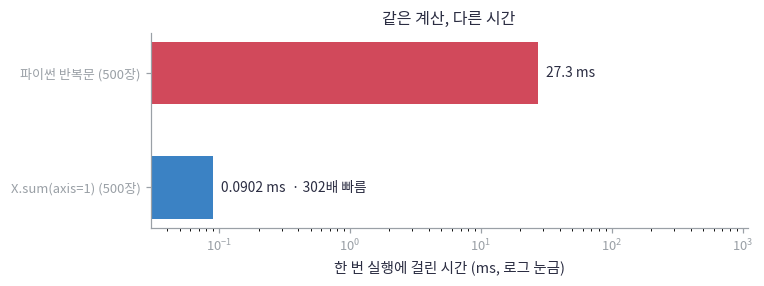

In [4]:
plot_timing_bars({"파이썬 반복문 (500장)": time_loop, "X.sum(axis=1) (500장)": time_vector})

🔍 **확인** · 결과는 같고 시간만 다릅니다. 반복문은 원소 392,000개마다 파이썬이 개입하고, 배열 연산은 그 반복을 NumPy 안의 C 코드가 대신합니다.
시간의 절대값은 컴퓨터마다 다르지만 배율은 보통 수십에서 수백 배입니다. 뒤의 학습 루프에서는 이 계산이 스텝마다 반복되므로 이 차이가 곧 "몇 분이냐 몇 시간이냐"가 됩니다.

📎 NumPy 연산 한 번에도 고정 비용(수 마이크로초)이 있습니다. 원소가 몇 개뿐인 아주 작은 배열에서는 반복문과 차이가 없거나 오히려 느릴 수 있습니다. 벡터화의 이득은 원소가 많을수록 커집니다.

## 🔑 2. 원소별 연산과 축 합: 반복문의 두 가지 모양

**이 절에서 가져갈 것:** 반복문 안이 "같은 자리끼리 계산"이면 원소별 연산(`*`, `+`, `np.exp`)이고, "더해서 하나로"면 축 합(`sum(axis=…)`)입니다. `keepdims=True`는 없앤 축을 길이 1로 남겨 다시 브로드캐스팅하게 합니다.

> **용어**
>
> - **원소별 연산(elementwise)**: 같은 모양의 두 배열에서 같은 자리끼리 계산하는 것. `A * B`, `A + B`, `np.exp(A)`. 모양은 그대로입니다.
> - **축 합(reduction)**: 한 축을 따라 더하거나 평균내 그 축을 없애는 것. `X.sum(axis=0)`은 행들을 더해 열만 남기고, `axis=1`은 반대입니다.
> - **`keepdims=True`**: 없앤 축을 길이 1인 축으로 남겨 두는 옵션. `(5000, 784).mean(axis=1, keepdims=True)`는 `(5000, 1)`입니다.

이미지 묶음에서 **평균 이미지를 빼는** 중심화를 두 가지로 씁니다. 평균 이미지 $\bar x$는 샘플 축의 평균이고, 빼기는 이미지마다 같은 $\bar x$를 빼는 원소별 연산입니다.

$$\bar x_d=\frac1N\sum_n X_{nd},\qquad C_{nd}=X_{nd}-\bar x_d.$$


In [5]:
mean_image = X.mean(axis=0)                                 # (784,): 샘플 축을 없앰
centered = X - mean_image                                   # (5000, 784) − (784,) → 브로드캐스팅
centered_examples = X_examples - mean_image                 # 예시 10장도 같은 평균을 뺌
assert mean_image.shape == (784,) and centered.shape == X.shape
np.testing.assert_allclose(centered.mean(axis=0), 0, atol=1e-12)   # 중심화하면 평균이 0
print("평균 이미지의 잉크 양", mean_image.sum().round(1), "· 중심화 뒤 최댓값", centered.max().round(3))

평균 이미지의 잉크 양 102.1 · 중심화 뒤 최댓값 1.0


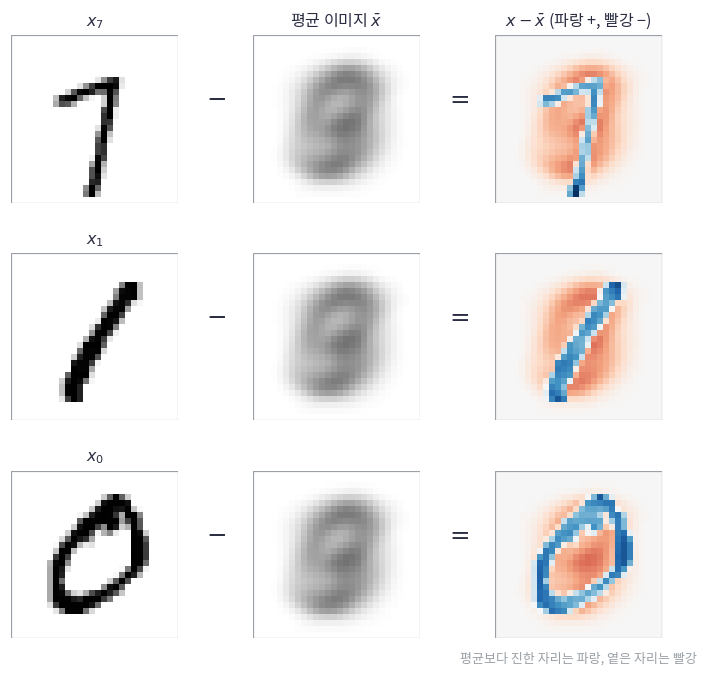

In [6]:
plot_centering([example_images[7], example_images[1], example_images[0]], mean_image.reshape(28, 28),
               [centered_examples[7].reshape(28, 28), centered_examples[1].reshape(28, 28), centered_examples[0].reshape(28, 28)], [7, 1, 0])

🔍 **확인** · 평균 이미지는 모든 숫자가 겹친 흐릿한 덩어리이고, 이미지에서 이것을 빼면 "평균보다 진한 자리(파랑)"와 "옅은 자리(빨강)"만 남습니다.
`X - mean_image`는 반복문 없이 5,000장 모두에 같은 평균을 뺐습니다. `(5000, 784)`와 `(784,)`의 모양이 다른데도 계산된 이유가 다음 절의 브로드캐스팅입니다.

아래는 같은 계산을 반복문으로 쓴 것과 대조한 검산입니다.

In [7]:
def center_loop(X):
    mean_row = np.zeros(X.shape[1])
    for n in range(len(X)):                                 # 축 합: 샘플을 하나씩 더함
        mean_row += X[n]
    mean_row /= len(X)
    result = np.empty_like(X)
    for n in range(len(X)):                                 # 원소별: 이미지마다 같은 평균을 뺌
        result[n] = X[n] - mean_row
    return result


np.testing.assert_allclose(center_loop(X[:200]), centered[:200] + mean_image - X[:200].mean(axis=0))
ink_keep = X.sum(axis=1, keepdims=True)                     # (5000, 1)
normalized = X / np.maximum(ink_keep, 1e-12)                # 이미지마다 잉크 양으로 나눔 → 행마다 합 1
np.testing.assert_allclose(normalized.sum(axis=1), 1)
print("keepdims 모양", ink_keep.shape, "· 행 합", normalized.sum(axis=1)[:3])

keepdims 모양 (5000, 1) · 행 합 [1. 1. 1.]


🔍 **확인** · `keepdims=True`가 없으면 `X.sum(axis=1)`은 `(5000,)`이 되어 `(5000, 784)`와 나눌 때 뒤 축 784와 5000이 맞지 않아 오류가 납니다.
`(5000, 1)`로 남겨 두면 각 행을 그 행의 합으로 나눌 수 있습니다. 02번의 softmax(행마다 합 1)와 08번의 attention이 정확히 이 계산입니다.

## 🔑 3. 브로드캐스팅: 모양이 다른 배열을 반복문 없이 맞추기

**이 절에서 가져갈 것:** 두 배열을 **뒤 축부터** 맞춰 봅니다. 같으면 통과, 한쪽이 1이면 그쪽을 늘려 쓰고, 축이 없으면 앞에 1을 붙입니다. 어긋나면 오류입니다.

> **용어**
>
> - **브로드캐스팅(broadcasting)**: 모양이 다른 배열을 연산할 때 NumPy가 작은 쪽을 복사하지 않고 "늘려 쓰는" 규칙. 00번 5절에서 편향을 더할 때 이미 썼습니다.
> - **새 축 추가** `[:, None]`, `[None, :]`: 길이 1인 축을 끼워 넣어 어느 방향으로 늘릴지 정하는 방법.

규칙 세 줄입니다.

1. 두 모양을 오른쪽 끝에서부터 정렬합니다.
2. 자리마다 비교합니다. 같으면 통과, 한쪽이 1이면 그 축을 상대 길이로 늘립니다.
3. 한쪽에 축이 없으면 앞에 길이 1인 축이 있다고 봅니다. 같지도 않고 1도 아니면 오류입니다.

| 계산 | 모양 | 결과 |
|---|---|---|
| `X - mean_image` | `(5000, 784)`, `(784,)` | `(5000, 784)` |
| `X / ink_keep` | `(5000, 784)`, `(5000, 1)` | `(5000, 784)` |
| `a[:, None] * b[None, :]` | `(10, 1)`, `(1, 784)` | `(10, 784)` 바깥곱 |
| `X - ink` | `(5000, 784)`, `(5000,)` | 오류 (784와 5000) |


In [8]:
cases = [
    ((5000, 784), "−", (784,), (5000, 784), "평균 이미지 빼기: 뒤 축 784가 같고 앞은 없으니 1로"),
    ((5000, 784), "÷", (5000, 1), (5000, 784), "행마다 나누기: 1인 축을 784로 늘림"),
    ((10, 1), "×", (1, 784), (10, 784), "바깥곱: 서로 다른 축을 각각 늘림"),
    ((10, 1, 784), "−", (1, 10, 784), (10, 10, 784), "쌍마다 차이: 이미지 10 × 이미지 10 × 화소"),
    ((5000, 784), "−", (5000,), None, "784와 5000이 어긋남 → [:, None]으로 세워야 함"),
]
for a, _, b, result, _ in cases:
    if result is not None:
        assert np.broadcast_shapes(a, b) == result          # NumPy가 계산한 결과 모양과 같은지
print("결과 모양을 먼저 적고, np.broadcast_shapes로 검산할 수 있습니다.")

결과 모양을 먼저 적고, np.broadcast_shapes로 검산할 수 있습니다.


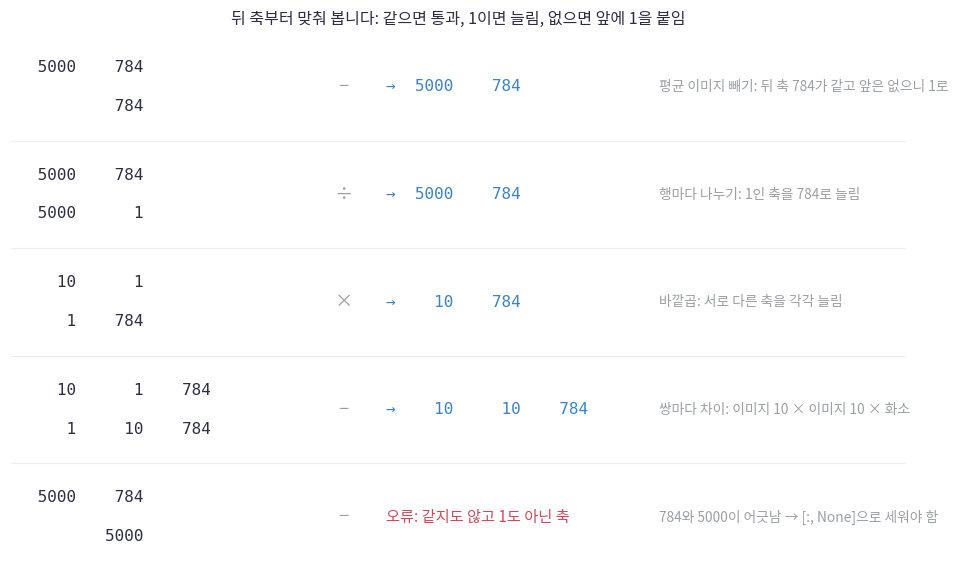

In [9]:
plot_broadcast_shapes(cases)

🔍 **확인** · 네 번째 줄이 이 절의 실전입니다. 이미지 10장 `(10, 784)`와 평균 이미지 10장 `(10, 784)`의 **모든 쌍**의 차이를 구하려면
한쪽은 `[:, None, :]`로 `(10, 1, 784)`, 다른 쪽은 `[None, :, :]`로 `(1, 10, 784)`를 만듭니다. 결과 `(10, 10, 784)`에서 화소 축을 합하면 거리표 `(10, 10)`입니다.

숫자마다 평균 이미지를 만들고, 예시 10장이 어느 평균에 가장 가까운지로 숫자를 맞혀 봅니다. 학습 없이 브로드캐스팅만으로 만드는 분류기입니다.

In [10]:
class_means = np.stack([X[y == k].mean(axis=0) for k in range(10)])       # (10, 784): 숫자별 평균 이미지
differences = X_examples[:, None, :] - class_means[None, :, :]             # (10, 1, 784) − (1, 10, 784) → (10, 10, 784)
distances = (differences ** 2).sum(axis=2)                                 # (10, 10): 화소 축을 없앰
nearest = distances.argmin(axis=1)                                         # 행마다 가장 가까운 평균
assert differences.shape == (10, 10, 784) and distances.shape == (10, 10)
np.testing.assert_allclose(distances[7, 7], ((X_examples[7] - class_means[7]) ** 2).sum())   # 한 칸 손계산
print("가장 가까운 평균:", nearest, "· 정답:", example_labels, "· 맞은 수", (nearest == example_labels).sum())

가장 가까운 평균: [0 1 2 3 4 5 6 7 8 9] · 정답: [0 1 2 3 4 5 6 7 8 9] · 맞은 수 10


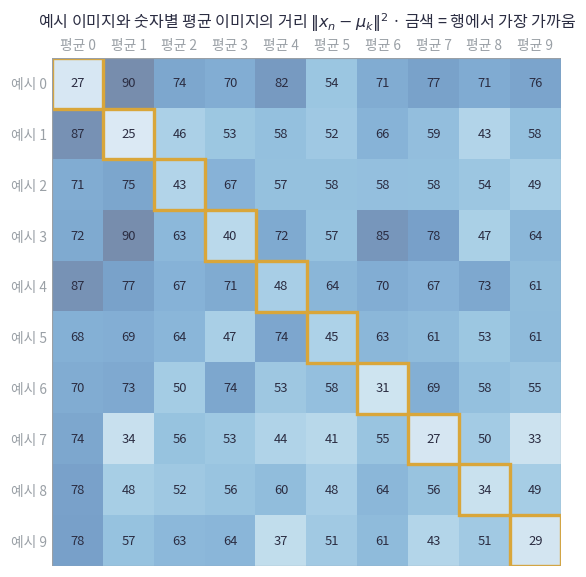

In [11]:
plot_distance_grid(distances, [f"예시 {l}" for l in example_labels], [f"평균 {k}" for k in range(10)],
                   "예시 이미지와 숫자별 평균 이미지의 거리 $\\|x_n - \\mu_k\\|^2$ · 금색 = 행에서 가장 가까움")

🔍 **확인** · 반복문 두 겹(이미지 × 평균)을 브로드캐스팅 한 줄로 바꿨고, 10장 모두 자기 숫자의 평균에 가장 가깝습니다.
`(10, 10, 784)`는 원소 78,400개라 괜찮지만, 5,000장 전체를 같은 방식으로 하면 `(5000, 10, 784)`, 원소 3,920만 개(313 MB)가 됩니다.
5절에서 메모리를 쓰지 않는 다른 벡터화를 봅니다.

## 🔑 4. 인덱싱: 조건으로 고르고, 번호로 고르고, 쌍으로 고르기

**이 절에서 가져갈 것:** 반복문 안의 `if`는 마스크 인덱싱, "몇 번째 것"은 정수 배열 인덱싱, "행마다 정답 열 하나"는 `P[np.arange(N), y]`로 씁니다.

> **용어**
>
> - **마스크(boolean) 인덱싱**: `y == 7`처럼 True/False 배열로 True인 행만 고르기. `X[y == 7]`은 7인 이미지만 모은 `(n7, 784)`.
> - **정수 배열 인덱싱(fancy indexing)**: 번호 배열로 고르기. `X[[3, 0, 3]]`은 3번, 0번, 3번 행. 미니배치를 뽑을 때 씁니다.
> - **one-hot**: 정답 $y$를 길이 $K$ 벡터로 쓴 것. `np.eye(K)[y]`가 `(N, K)` 한 줄입니다.
> - **쌍으로 고르기**: `P[rows, cols]`는 `(rows[n], cols[n])` 칸 N개를 한 번에 고릅니다. 02번의 cross-entropy에서 정답 확률을 고를 때 씁니다.


In [12]:
mask_7 = y == 7                                             # (5000,) True/False
sevens = X[mask_7]                                          # 7인 이미지만
np.testing.assert_allclose(sevens.mean(axis=0), class_means[7])    # 3절의 평균과 같음
picked = X[np.array([3, 0, 3])]                             # 번호로 고르기 (중복 가능)
assert picked.shape == (3, 784) and np.array_equal(picked[0], picked[2])
onehot = np.eye(10)[example_labels]                         # (10, 10)
np.testing.assert_array_equal(onehot.sum(axis=1), 1)
rng_idx = np.random.default_rng(0)
P_small = rng_idx.random((3, 4)); P_small /= P_small.sum(axis=1, keepdims=True)   # 확률표 3×4
rows, targets = np.arange(3), np.array([2, 0, 3])
chosen = P_small[rows, targets]                             # (3,): 행 0의 열 2, 행 1의 열 0, 행 2의 열 3
np.testing.assert_allclose(chosen, [P_small[0, 2], P_small[1, 0], P_small[2, 3]])
print("7의 수", mask_7.sum(), "· one-hot 모양", onehot.shape, "· 고른 확률", chosen.round(3))

7의 수 550 · one-hot 모양 (10, 10) · 고른 확률 [0.042 0.266 0.001]


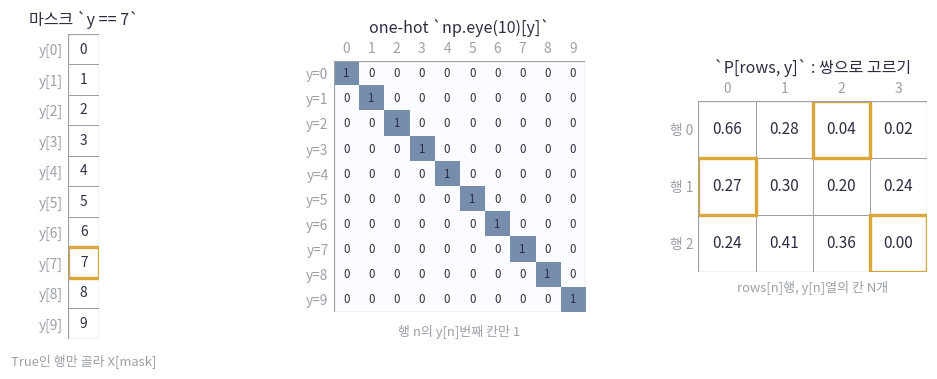

In [13]:
plot_indexing(example_labels, example_labels == 7, onehot, P_small, rows, targets)

🔍 **확인** · 왼쪽은 마스크가 True인 행만 고른 것이고, 가운데 one-hot은 행마다 정답 자리만 1입니다. 오른쪽은 `P[rows, y]`가 고른 칸 세 개입니다.
반복문으로 쓰면 `for n in range(N): chosen[n] = P[n, y[n]]`인데, 이것이 02번 cross-entropy의 `-log_probabilities[rows, targets].mean()`입니다.

📎 `X[mask]`와 `X[번호 배열]`은 **복사본**을 만듭니다. `X[:5]` 같은 슬라이스는 원본을 가리키는 뷰입니다. 6절에서 다시 봅니다.

## 🔍 5. 실전: 가장 가까운 평균 분류기를 전부 벡터화

3절의 분류기를 5,000장 전체에 적용합니다. `(5000, 10, 784)`를 만들지 않고 거리를 전개합니다.

$$\|x-\mu\|^2=\|x\|^2-2\,x\cdot\mu+\|\mu\|^2.$$

첫 항은 `(5000, 1)`, 둘째 항은 행렬곱 `(5000, 10)`, 셋째 항은 `(1, 10)`이라 브로드캐스팅으로 `(5000, 10)`이 됩니다. 메모리는 40만 개 원소뿐입니다.
평균 이미지도 반복문 없이 만들 수 있습니다. one-hot `T`를 쓰면 `T.T @ X`가 숫자별 화소 합이고, `T.sum(axis=0)`이 숫자별 개수입니다.

In [14]:
T = np.eye(10)[y]                                            # (5000, 10)
means_vectorized = T.T @ X / T.sum(axis=0)[:, None]          # (10, 784): 반복문 없이 숫자별 평균
np.testing.assert_allclose(means_vectorized, class_means)


def nearest_mean_loop(X, means):
    predictions = np.empty(len(X), dtype=int)
    for n in range(len(X)):
        best, best_distance = -1, np.inf
        for k in range(len(means)):
            distance = np.sum((X[n] - means[k]) ** 2)
            if distance < best_distance:
                best, best_distance = k, distance
        predictions[n] = best
    return predictions


def nearest_mean_vectorized(X, means):
    squared = (X ** 2).sum(axis=1, keepdims=True) - 2 * X @ means.T + (means ** 2).sum(axis=1)[None, :]   # (N, 10)
    return squared.argmin(axis=1)


np.testing.assert_array_equal(nearest_mean_loop(X[:300], class_means), nearest_mean_vectorized(X[:300], class_means))
predictions = nearest_mean_vectorized(X, class_means)
accuracy = (predictions == y).mean()
time_loop_nm = elapsed(lambda: nearest_mean_loop(X[:300], class_means), repeats=1)
time_vec_nm = elapsed(lambda: nearest_mean_vectorized(X[:300], class_means), repeats=20)
print(f"5,000장 정확도 {accuracy:.1%} · 300장 기준 반복문 {time_loop_nm*1e3:.1f} ms, 벡터화 {time_vec_nm*1e3:.3f} ms")

5,000장 정확도 81.3% · 300장 기준 반복문 24.7 ms, 벡터화 0.383 ms


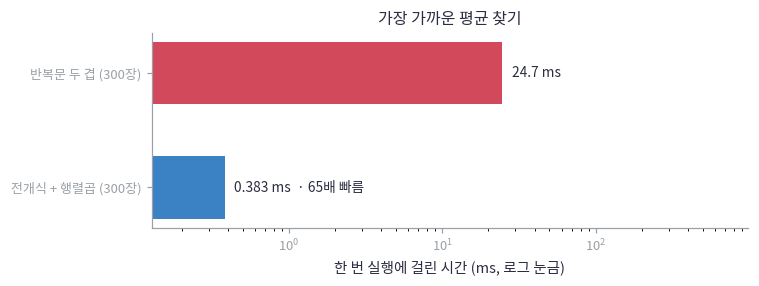

In [15]:
plot_timing_bars({"반복문 두 겹 (300장)": time_loop_nm, "전개식 + 행렬곱 (300장)": time_vec_nm}, "가장 가까운 평균 찾기")

🔍 **확인** · 학습 없이 평균만으로 5,000장의 81% 안팎을 맞힙니다(정확한 값은 위 출력). 01번부터의 학습은 이 평균 템플릿을 손실이 줄어드는 방향으로 고치는 일입니다.
같은 답을 내는 두 함수의 시간 차이가 벡터화의 이유이고, 전개식은 큰 중간 배열을 만들지 않는 벡터화의 예입니다.

## 📎 6. 흔한 함정 네 가지

- **뷰와 복사.** 슬라이스 `X[:5]`는 원본을 가리키는 뷰라서 고치면 원본도 바뀝니다. 마스크·번호 인덱싱과 `.copy()`는 복사본입니다.
- **dtype.** MNIST 원본은 `uint8`(0부터 255)입니다. `uint8`끼리 더하면 255를 넘을 때 값이 돌아갑니다. `load_mnist`가 실수로 바꿔 주는 이유입니다.
- **오류 메시지 읽기.** `operands could not be broadcast together with shapes (5000,784) (5000,)`는 "뒤 축 784와 5000이 어긋난다"는 뜻입니다. `[:, None]`으로 세우면 됩니다.
- **반복문 안의 append.** 리스트에 하나씩 붙이고 마지막에 `np.array`로 바꾸는 것보다, 결과 모양을 알면 `np.empty`로 미리 만들어 채우는 것이 빠릅니다. 배열 연산으로 바꿀 수 있으면 그것이 가장 빠릅니다.

In [16]:
view = X[:2]                                                # 뷰
copy = X[:2].copy()                                         # 복사
original_value = X[0, 100]
view[0, 100] = -1.0                                         # 원본이 바뀜
assert X[0, 100] == -1.0 and copy[0, 100] == original_value
X[0, 100] = original_value                                  # 되돌림
small = np.array([200, 100], dtype=np.uint8)
wrapped = (small[:1] + small[1:])[0]                       # uint8 배열끼리 더하면 255를 넘을 때 값이 돌아감
print("uint8 200 + 100 =", int(wrapped), "(255를 넘어 돌아감) · 실수로 바꾸면", float(small[0]) + float(small[1]))
try:
    X - X.sum(axis=1)
except ValueError as error:
    print("오류 메시지:", error)

uint8 200 + 100 = 44 (255를 넘어 돌아감) · 실수로 바꾸면 300.0
오류 메시지: operands could not be broadcast together with shapes (5000,784) (5000,) 


## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 행마다 표준화 (2절)

이미지마다 자기 평균을 빼고 자기 표준편차로 나눕니다. `keepdims=True`로 `(N, 1)`을 만드는 두 줄을 채우세요.

In [17]:
def exercise_standardize_rows(X):
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: row_mean = 행마다 평균 (N, 1), row_std = 행마다 표준편차 (N, 1)
    ### 힌트: X.mean(axis=1, keepdims=True), X.std(axis=1, keepdims=True)
    raise NotImplementedError
    return (X - row_mean) / row_std

In [18]:
def check_standardize(candidate):
    Z = candidate(X_examples)
    assert Z.shape == (10, 784)
    np.testing.assert_allclose(Z.mean(axis=1), 0, atol=1e-12)
    np.testing.assert_allclose(Z.std(axis=1), 1)
    print("행마다 표준화: 각 행의 평균 0, 표준편차 1입니다.")

run_check(check_standardize, exercise_standardize_rows, hint="row_mean = X.mean(axis=1, keepdims=True); row_std = X.std(axis=1, keepdims=True)")

☐ exercise_standardize_rows: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: row_mean = X.mean(axis=1, keepdims=True); row_std = X.std(axis=1, keepdims=True)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
row_mean = X.mean(axis=1, keepdims=True)
row_std = X.std(axis=1, keepdims=True)
```

</details>

### ✏️ 연습 B · 모든 쌍의 제곱 거리 (3절)

`A`는 `(N, D)`, `B`는 `(M, D)`입니다. 결과 `(N, M)`의 `[n, m]` 칸이 `A[n]`과 `B[m]`의 제곱 거리가 되도록 브로드캐스팅 한 줄을 채우세요.

In [19]:
def exercise_pairwise_sq_dist(A, B):
    assert A.shape[1] == B.shape[1]
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: (N, 1, D) − (1, M, D) 의 제곱을 화소 축(axis=2)으로 더한 (N, M)
    ### 힌트: A[:, None, :] 과 B[None, :, :] 을 빼고 ** 2 한 뒤 .sum(axis=2)
    raise NotImplementedError
    return D

In [20]:
def check_pairwise(candidate):
    D = candidate(X_examples, class_means)
    assert D.shape == (10, 10)
    np.testing.assert_allclose(D, distances)                          # 3절 결과와 같아야 합니다
    np.testing.assert_allclose(candidate(np.array([[0., 0.], [3., 4.]]), np.array([[0., 0.]])), [[0.], [25.]])
    print("쌍마다 제곱 거리: 3절의 거리표와 일치합니다.")

run_check(check_pairwise, exercise_pairwise_sq_dist, hint="D = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)")

☐ exercise_pairwise_sq_dist: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: D = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
D = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)
```

</details>

### ✏️ 연습 C · one-hot 만들기 (4절)

정수 라벨 `(N,)`을 `(N, K)` one-hot으로 바꾸는 한 줄을 채우세요.

In [21]:
def exercise_one_hot(labels, K):
    labels = np.asarray(labels)
    assert labels.ndim == 1 and labels.min() >= 0 and labels.max() < K
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 행 n의 labels[n]번째 칸만 1인 (N, K) 배열
    ### 힌트: 단위행렬 np.eye(K)의 행을 labels로 고릅니다.
    raise NotImplementedError
    return T

In [22]:
def check_one_hot(candidate):
    T = candidate(np.array([2, 0, 1]), 3)
    np.testing.assert_array_equal(T, [[0, 0, 1], [1, 0, 0], [0, 1, 0]])
    np.testing.assert_array_equal(candidate(example_labels, 10), onehot)
    print("one-hot: 손계산과 일치합니다.")

run_check(check_one_hot, exercise_one_hot, hint="T = np.eye(K)[labels]")

☐ exercise_one_hot: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: T = np.eye(K)[labels]


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
T = np.eye(K)[labels]
```

</details>

### ✏️ 연습 D · 행마다 softmax (2·3절)

점수표 `Z` `(N, K)`의 행마다 softmax를 만듭니다. 행의 최댓값을 빼는 줄과, 지수를 행 합으로 나누는 줄을 채우세요. `keepdims=True`가 핵심입니다.

In [23]:
def exercise_row_softmax(Z):
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: shifted = Z − 행마다 최댓값 (N, 1), P = exp(shifted) / 행마다 합 (N, 1)
    ### 힌트: Z.max(axis=1, keepdims=True), np.exp(shifted).sum(axis=1, keepdims=True)
    raise NotImplementedError
    return P

In [24]:
def check_row_softmax(candidate):
    P = candidate(np.array([[0., 0., 0.], [np.log(2), 0., 0.]]))
    np.testing.assert_allclose(P, [[1/3, 1/3, 1/3], [0.5, 0.25, 0.25]])
    big = candidate(np.array([[1000., 0.]]))
    assert np.all(np.isfinite(big)) and np.isclose(big.sum(), 1)
    print("행마다 softmax: 행 합 1이고 큰 점수에서도 유한합니다.")

run_check(check_row_softmax, exercise_row_softmax, hint="shifted = Z - Z.max(axis=1, keepdims=True); P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)")

☐ exercise_row_softmax: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: shifted = Z - Z.max(axis=1, keepdims=True); P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
shifted = Z - Z.max(axis=1, keepdims=True)
P = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
```

</details>

### ✏️ 준비도 질문 · 다음 노트북으로 갈 준비

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

1. `(5000, 784)`에서 이미지마다 평균을 빼는 코드와, 화소마다 평균을 빼는 코드를 구분해 쓸 수 있나요?
2. `(N, D)`와 `(M, D)`에서 모든 쌍의 거리를 만들 때 어느 쪽에 `None`을 넣을지 말할 수 있나요? 결과 모양은요?
3. `P[np.arange(N), y]`가 반복문으로는 무엇인지 설명할 수 있나요?
4. 반복문 하나를 골라 "축·원소별·합·브로드캐스팅·고르기" 중 무엇으로 옮길지 말할 수 있나요?

**다음:** [01 · 미분으로 학습시키기](01_gradients_and_learning.ipynb). 학습 루프의 네 줄이 모두 이 노트북의 연산입니다.